In [1]:
import pathlib
data_dir = pathlib.Path('./flower_photos')
data_dir

WindowsPath('flower_photos')

In [3]:
import tensorflow as tf
from tensorflow import keras

model = keras.models.load_model('./pkl/20260601_flower_efficientnetv2b0.keras')
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ input_layer_8[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling_3[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1a_project_… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_co… │ (None, 56, 56,    │      2,048 │ block2a_expand_a… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_project_bn  │ (None, 56, 56,    │        128 │ block2a_project_… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_conv │ (None, 56, 56,    │     36,864 │ block2a_project_… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_bn   │ (None, 56, 56,    │        512 │ block2b_expand_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2b_expand_act… │ (None, 56, 56,    │          0 │ block2b_expand_b

 Total params: 6,906,977 (26.35 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

 Optimizer params: 658,444 (2.51 MB)

In [4]:
# 훈련 세트 읽기
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    shuffle=True,
    image_size=(224,224),
    batch_size=32
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [5]:
# 검증 세트 읽기
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    shuffle=False,
    image_size=(224,224),
    batch_size=32
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

model1 = Sequential([
    layers.Input(shape=(224,224,3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),         # 360*0.1 = 36도 회전
    layers.RandomZoom(0.1)              # 10% 범위로 +- 적용
])

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

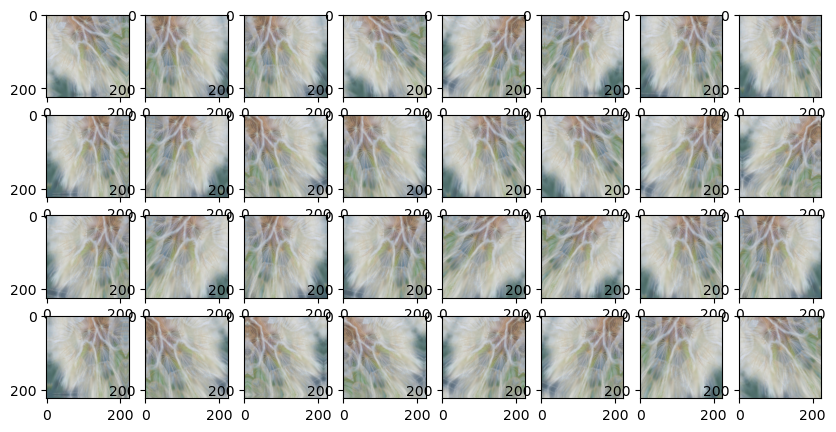

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

# batch=32개의 이미지를 가져옴
for image, _ in train_ds.take(1):
    for i in range(32):
        changeimg = model1(image)
        plt.subplot(4, 8, i+1)
        plt.imshow(changeimg[0].numpy().astype("uint8"))

In [19]:
# EfficientNetV2B0
from tensorflow import keras
from tensorflow.keras import layers

inputs = keras.Input(shape=(224, 224, 3))

x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.3)(x)           # 360*0.1 = 36도 회전
x = layers.RandomZoom(0.2)(x)               # 10% 범위로 +- 적용

base_model = keras.applications.EfficientNetV2B0(
    include_top=False,      # 분류기 제거
    weights="imagenet",     # 사전학습 사용 안함
    input_tensor=x
)
base_model.trainable = False    # 특징추출기 가충치 업데이트 안함

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(5, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#model.summary()

In [22]:
history = model.fit(train_ds, validation_data=val_ds, epochs=10, verbose=2)

Epoch 1/10
92/92 - 46s - 503ms/step - accuracy: 0.9605 - loss: 0.1076 - val_accuracy: 0.9728 - val_loss: 0.0946
Epoch 2/10
92/92 - 79s - 860ms/step - accuracy: 0.9687 - loss: 0.0975 - val_accuracy: 0.9659 - val_loss: 0.1368
Epoch 3/10
92/92 - 67s - 733ms/step - accuracy: 0.9636 - loss: 0.0912 - val_accuracy: 0.9687 - val_loss: 0.1133
Epoch 4/10
92/92 - 80s - 873ms/step - accuracy: 0.9670 - loss: 0.0900 - val_accuracy: 0.9741 - val_loss: 0.0827
Epoch 5/10
92/92 - 73s - 792ms/step - accuracy: 0.9680 - loss: 0.0876 - val_accuracy: 0.9673 - val_loss: 0.1208
Epoch 6/10
92/92 - 68s - 738ms/step - accuracy: 0.9700 - loss: 0.0787 - val_accuracy: 0.9796 - val_loss: 0.0880
Epoch 7/10
92/92 - 79s - 863ms/step - accuracy: 0.9772 - loss: 0.0676 - val_accuracy: 0.9768 - val_loss: 0.1150
Epoch 8/10
92/92 - 71s - 776ms/step - accuracy: 0.9721 - loss: 0.0714 - val_accuracy: 0.9796 - val_loss: 0.0857
Epoch 9/10
92/92 - 78s - 843ms/step - accuracy: 0.9751 - loss: 0.0726 - val_accuracy: 0.9578 - val_loss:

In [23]:
model.save('./pkl/20260602_flower.keras')

In [26]:
# 동영상을 이미지로 변경 샘플링
import cv2
import os

video_path = "./video/flower.mp4"
output_path = "image"

# frame 폴더생성
os.makedirs(output_path, exist_ok=True)

cap = cv2.VideoCapture(video_path)
frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx % 20 ==0:
        filename = os.path.join(output_path, f"frame_{frame_idx:05d}.jpg")
        cv2.imwrite(filename, frame)
    
    frame_idx += 1

cap.release()

In [1]:
import cv2
from tensorflow import keras
import numpy as np

model = keras.models.load_model('./pkl/20260602_flower.keras')
class_names = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

video_path = "./video/flower.mp4"
cap = cv2.VideoCapture(video_path)
frame_idx = 0

if not cap.isOpened():
    print("비디오 없음😯")
    exit()

label = ""  # 20프레임마다 갱신되니까 유지용 변수

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx % 5 == 0:
        img = cv2.resize(frame, (224, 224))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # ✅ BGR→RGB
        img = img[None, ...]

        pred = model.predict(img, verbose=0)
        class_idx = pred.argmax()
        label = f"{class_names[class_idx]} {pred[0][class_idx]:.2f}"

    cv2.putText(frame, label, (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow('video classification', frame)
    frame_idx += 1

    if cv2.waitKey(30) & 0xFF == ord('q'):  # q 누르면 종료
        break

cap.release()
cv2.destroyAllWindows()